# EXPT NO: 1B
## Random Forest Regression – Baseball Databank
**Aim:** Prepare batting data and predict player-season runs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df=pd.read_csv("Batting.csv"); display(df.head())
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
print("Data Types:"); print(df.dtypes)

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


Shape: (101332, 22)
Columns: ['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']
Data Types:
playerID     object
yearID        int64
stint         int64
teamID       object
lgID         object
G             int64
AB          float64
R           float64
H           float64
2B          float64
3B          float64
HR          float64
RBI         float64
SB          float64
CS          float64
BB          float64
SO          float64
IBB         float64
HBP         float64
SH          float64
SF          float64
GIDP        float64
dtype: object


In [3]:
missing_values=df.isnull().sum(); display(missing_values.to_frame("Missing Values"))
before=len(df); df=df.drop_duplicates().copy(); after=len(df)
print("Rows before removing duplicates:",before)
print("Rows after removing duplicates:",after)
print("Duplicate rows removed:",before-after)

,Missing Values
playerID,0
yearID,0
stint,0
teamID,0
lgID,737
G,0
AB,5149
R,5149
H,5149
2B,5149


Rows before removing duplicates: 101332
Rows after removing duplicates: 101332
Duplicate rows removed: 0


In [4]:
features=["G","AB","H","2B","3B","HR","RBI","BB","SO","SB","CS"]
target="R"
for col in features+[target]: df[col]=pd.to_numeric(df[col],errors="coerce")
df=df.dropna(subset=features+[target]).copy()
print("Selected features:",features)
print("Target:",target)
print("Prepared dataset shape:",df.shape)

Selected features: ['G', 'AB', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB', 'CS']
Target: R
Prepared dataset shape: (72669, 22)


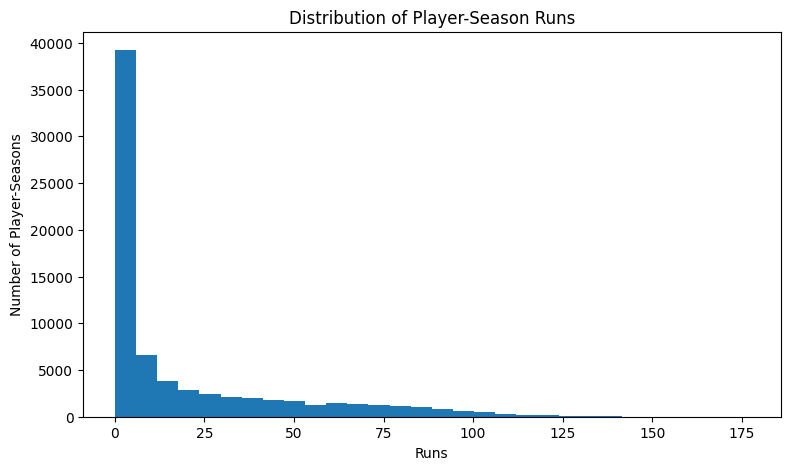

In [5]:
plt.figure(figsize=(9,5)); plt.hist(df["R"],bins=30); plt.title("Distribution of Player-Season Runs"); plt.xlabel("Runs"); plt.ylabel("Number of Player-Seasons"); plt.show()

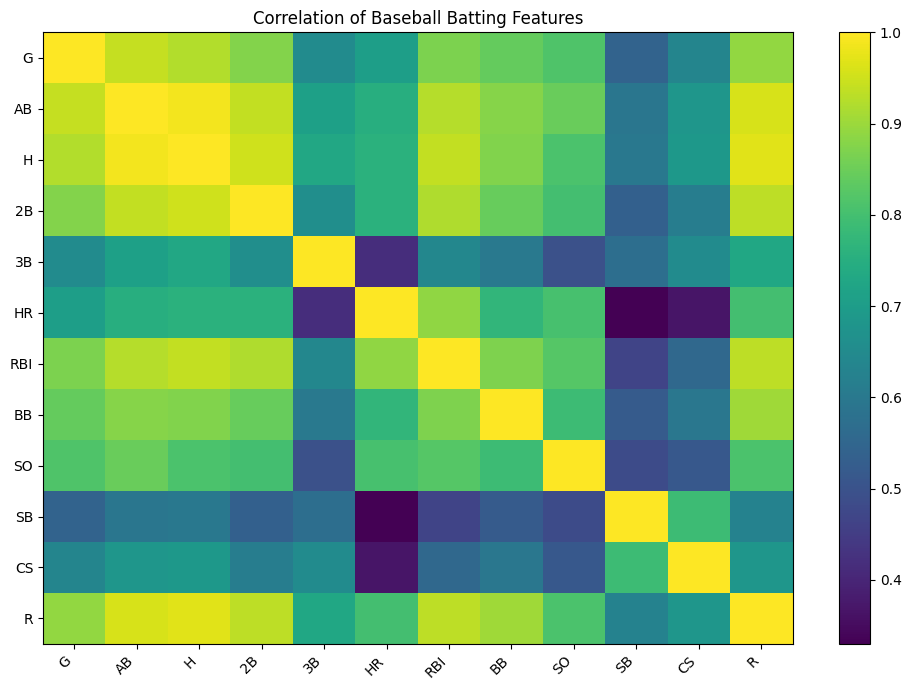

In [6]:
corr=df[features+[target]].corr(); plt.figure(figsize=(10,7)); plt.imshow(corr,aspect="auto"); plt.colorbar(); plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha="right"); plt.yticks(range(len(corr.columns)),corr.columns); plt.title("Correlation of Baseball Batting Features"); plt.tight_layout(); plt.show()

In [7]:
X=df[features]; y=df[target]
print("Input shape:",X.shape); print("Target shape:",y.shape); display(X.head()); display(y.head())

Input shape: (72669, 11)
Target shape: (72669,)


,G,AB,H,2B,3B,HR,RBI,BB,SO,SB,CS
0,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,25,118.0,32.0,6.0,0.0,0.0,13.0,4.0,0.0,8.0,1.0
2,29,137.0,40.0,4.0,5.0,0.0,19.0,2.0,5.0,3.0,1.0
3,27,133.0,44.0,10.0,2.0,2.0,27.0,0.0,2.0,1.0,1.0
4,25,120.0,39.0,11.0,3.0,0.0,16.0,2.0,1.0,6.0,2.0


0     0.0
1    30.0
2    28.0
3    28.0
4    29.0
Name: R, dtype: float64

In [8]:
sample_size=min(50000,len(df)); model_df=df.sample(n=sample_size,random_state=42); X=model_df[features]; y=model_df[target]; X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42); print("Training records:",len(X_train)); print("Testing records:",len(X_test))

Training records: 40000
Testing records: 10000


In [9]:
model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1); model.fit(X_train,y_train); print("Random Forest model trained successfully")

Random Forest model trained successfully


In [10]:
y_pred=model.predict(X_test); comparison=pd.DataFrame({"Actual Runs":y_test.to_numpy()[:15],"Predicted Runs":np.round(y_pred[:15],2)}); comparison

,Actual Runs,Predicted Runs
0,51.0,48.62
1,53.0,51.60
2,16.0,17.82
3,0.0,0.00
4,62.0,55.00
5,1.0,2.31
6,94.0,70.54
7,26.0,23.48
8,0.0,0.03
9,0.0,0.09


In [11]:
mae=mean_absolute_error(y_test,y_pred); r2=r2_score(y_test,y_pred); print(f"Mean Absolute Error (MAE): {mae:.4f}"); print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2.5544
R² Score: 0.9740


In [12]:
importance=pd.DataFrame({"Feature":features,"Importance":model.feature_importances_}).sort_values("Importance",ascending=False); importance

,Feature,Importance
2,H,0.943973
7,BB,0.017201
5,HR,0.009379
9,SB,0.006654
6,RBI,0.004107
8,SO,0.003998
0,G,0.003986
1,AB,0.003300
4,3B,0.002934
3,2B,0.002727


In [1]:
# Saved output generated from the supplied Baseball Databank.
# Run Runtime → Run all in Colab to regenerate.

Rows before removing duplicates: 101332
Rows after removing duplicates: 101332
Prepared dataset shape: (72669, 22)


Training records: 40000
Testing records: 10000
Random Forest model trained successfully


 Actual Runs  Predicted Runs
        51.0           48.62
        53.0           51.60
        16.0           17.82
         0.0            0.00
        62.0           55.00
         1.0            2.31
        94.0           70.54
        26.0           23.48
         0.0            0.03
         0.0            0.09
         1.0            2.30
         0.0            0.01
         0.0            0.01
        77.0           85.13
         0.0            0.00

Mean Absolute Error (MAE): 2.5544
R² Score: 0.9740


Feature  Importance
      H    0.943973
     BB    0.017201
     HR    0.009379
     SB    0.006654
    RBI    0.004107
     SO    0.003998
      G    0.003986
     AB    0.003300
     3B    0.002934
     2B    0.002727
     CS    0.001742